# RAPID2 Sandbox — run it live

[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/riverma/rapid-hub-1/main?labpath=docs/user-guide/tutorials/notebook-demo.ipynb)

*Click **launch binder** above to run this notebook in your browser — no install, no login required.*

This notebook mirrors the [Quick Start](../quick-start-sandbox.md): it downloads the synthetic
**Sandbox** river network (5 reaches, 2 gauges), runs RAPID2, and plots simulated vs. observed
discharge. On Binder the environment (`rapid2` + `matplotlib`) comes from the repo's `requirements.txt`.

## 1. Download the Sandbox and run RAPID2

`dsandbox` fetches the synthetic dataset from Zenodo; `rapid2` then routes the flow and writes
the simulated outflow (`Qou`).

In [1]:
import subprocess

def run(cmd):
    r = subprocess.run(cmd, capture_output=True, text=True)
    r.check_returncode()

run(["dsandbox"])                                                  # download Sandbox data
run(["rapid2", "--namelist", "input/Sandbox/nml_Sandbox_OL.yml"])  # run the model
print("Sandbox downloaded and RAPID2 run complete.")

Sandbox downloaded and RAPID2 run complete.


## 2. Plot simulated vs. observed hydrographs

Load the simulated outflow (`Qou`, 5 reaches) and the observations (`Qob`, 2 gauges) and compare
them at the two gauged reaches.

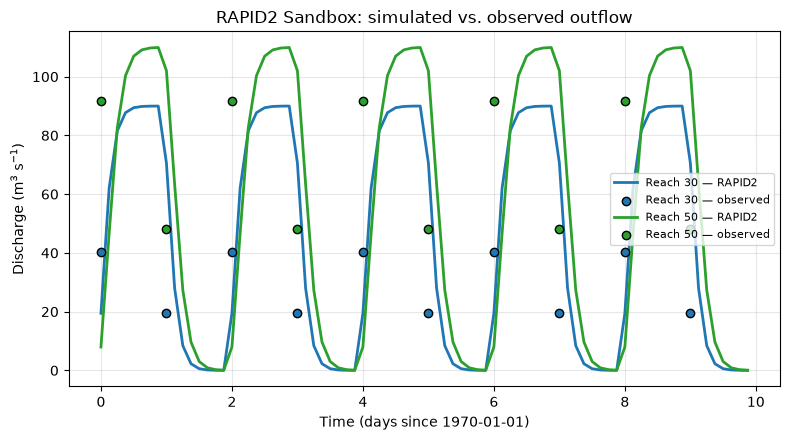

In [2]:
import matplotlib.pyplot as plt
from netCDF4 import Dataset

sim = Dataset("output/Sandbox/Qou_Sandbox_19700101_19700110_OL_tst.nc4")
obs = Dataset("input/Sandbox/Qob_Sandbox_19700101_19700110_TR.nc4")

sim_rivid = list(sim.variables["rivid"][:])
obs_rivid = list(obs.variables["rivid"][:])
sim_days  = (sim.variables["time"][:] - sim.variables["time"][0]) / 86400.0
obs_days  = (obs.variables["time"][:] - obs.variables["time"][0]) / 86400.0

fig, ax = plt.subplots(figsize=(8, 4.5))
colors = {30: "tab:blue", 50: "tab:green"}
for rid in obs_rivid:
    ax.plot(sim_days, sim.variables["Qout"][:, sim_rivid.index(rid)],
            color=colors[rid], lw=2, label=f"Reach {rid} — RAPID2")
    ax.scatter(obs_days, obs.variables["Qout"][:, obs_rivid.index(rid)],
               color=colors[rid], edgecolor="k", zorder=5, label=f"Reach {rid} — observed")

ax.set_xlabel("Time (days since 1970-01-01)")
ax.set_ylabel("Discharge (m$^3$ s$^{-1}$)")
ax.set_title("RAPID2 Sandbox: simulated vs. observed outflow")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()